# Question 3: Is There Overall Wage Discrimination at the University?

> *"The question is not just whether a gap exists — but how large it is, where it concentrates, and whether it survives rigorous statistical controls."*

In Questions 1 and 2 we found:
- **Q1:** Men's starting salaries are ~5% higher than women's, even after controlling for field, degree, rank, and experience
- **Q2:** No significant difference in salary *at the moment of promotion*, but women are promoted at nearly **half the rate** of men (24.4% vs 37.5%)

Now in Q3 we zoom out and ask: **overall, across all years, all ranks, all fields — is there a systematic salary gap by sex?**

We will build our answer progressively through three models, each adding more nuance, and use F-tests to justify every modelling decision.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'F': '#e74c3c', 'M': '#3498db'}

# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_csv('salary.txt', sep=r'\s+')
df  = raw.copy()
for c in ['sex', 'deg', 'field', 'rank']:
    df[c] = df[c].astype('category')
for c in ['case', 'id', 'yrdeg', 'startyr', 'year', 'admin']:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# ── Key derived variables ──────────────────────────────────────────────────────
df['years_since_deg'] = df['year'] - df['yrdeg']   # total career experience in current year

# Drop rows missing key variables
model_vars = ['salary','sex','field','deg','rank','admin','year','years_since_deg']
df_clean = df.dropna(subset=model_vars).copy()

print(f'Full panel: {len(df_clean):,} observations | {df_clean["id"].nunique():,} unique faculty')
print(f'Sex split: {(df_clean["sex"]=="F").sum():,} Female rows | {(df_clean["sex"]=="M").sum():,} Male rows')
df_clean.head()

Full panel: 19,788 observations | 1,597 unique faculty
Sex split: 3,926 Female rows | 15,862 Male rows


,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary,years_since_deg
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0,3
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.0,3
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0,4
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0,-1
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.0,25


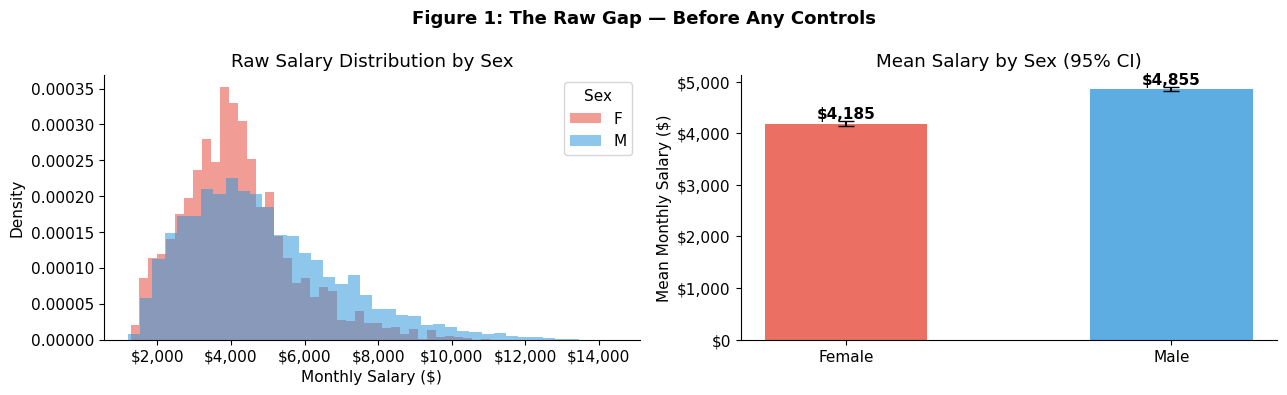

In [4]:
# ── Figure 1: Raw salary distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sex, grp in df_clean.groupby('sex', observed=True):
    axes[0].hist(grp['salary'], bins=40, alpha=0.55, color=COLORS[sex], label=sex, density=True)
axes[0].set_title('Raw Salary Distribution by Sex')
axes[0].set_xlabel('Monthly Salary ($)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Sex')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

means = df_clean.groupby('sex', observed=True)['salary'].mean()
sems  = df_clean.groupby('sex', observed=True)['salary'].sem()
axes[1].bar(['Female','Male'], means.values, yerr=1.96*sems.values,
            color=['#e74c3c','#3498db'], alpha=0.8, capsize=6, width=0.5)
axes[1].set_title('Mean Salary by Sex (95% CI)')
axes[1].set_ylabel('Mean Monthly Salary ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, (v, s) in enumerate(zip(means.values, sems.values)):
    axes[1].text(i, v + 1.96*s + 50, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Figure 1: The Raw Gap — Before Any Controls', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## The raw gap looks large. But is it really discrimination, or are there other explanations?

---
## Model 1: Sex Alone

We start with the simplest possible model — just sex as a predictor. This gives us the **unadjusted regression estimate** of the sex gap, equivalent to a t-test.

> **Model 1:** `salary ~ C(sex)`

In [6]:
# ── Model 1: Sex only ──────────────────────────────────────────────────────────
m1 = smf.ols('salary ~ C(sex)', data=df_clean).fit(cov_type='HC3')
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     520.5
Date:                Thu, 12 Mar 2026   Prob (F-statistic):          9.50e-114
Time:                        14:31:24   Log-Likelihood:            -1.7817e+05
No. Observations:               19788   AIC:                         3.564e+05
Df Residuals:                   19786   BIC:                         3.564e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    4185.4623     24.316    172.129      

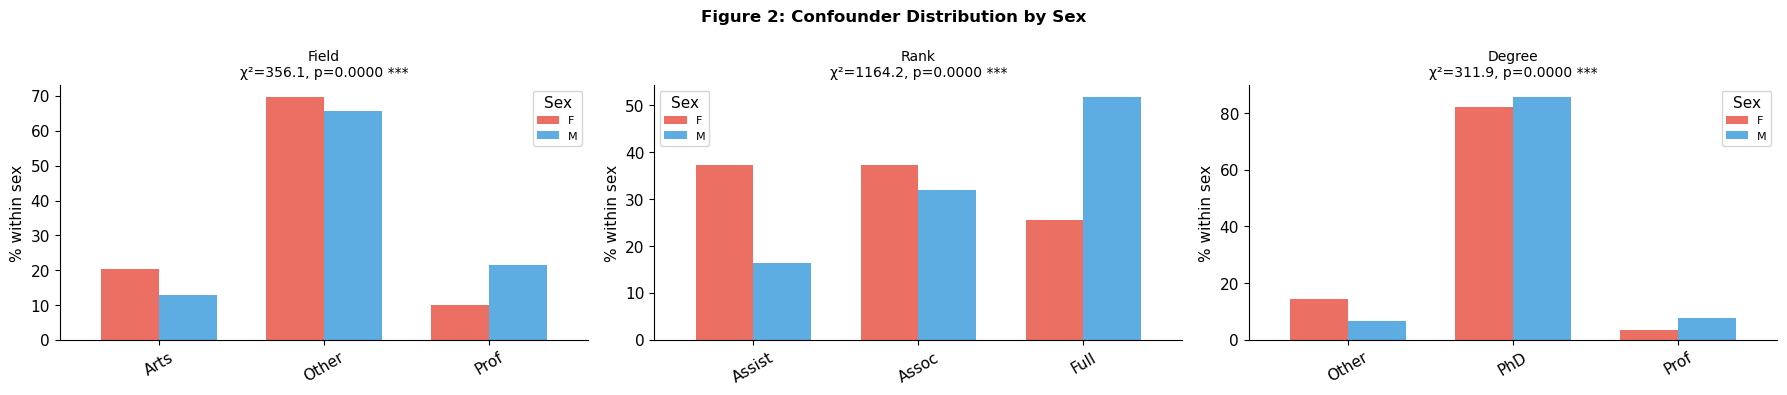

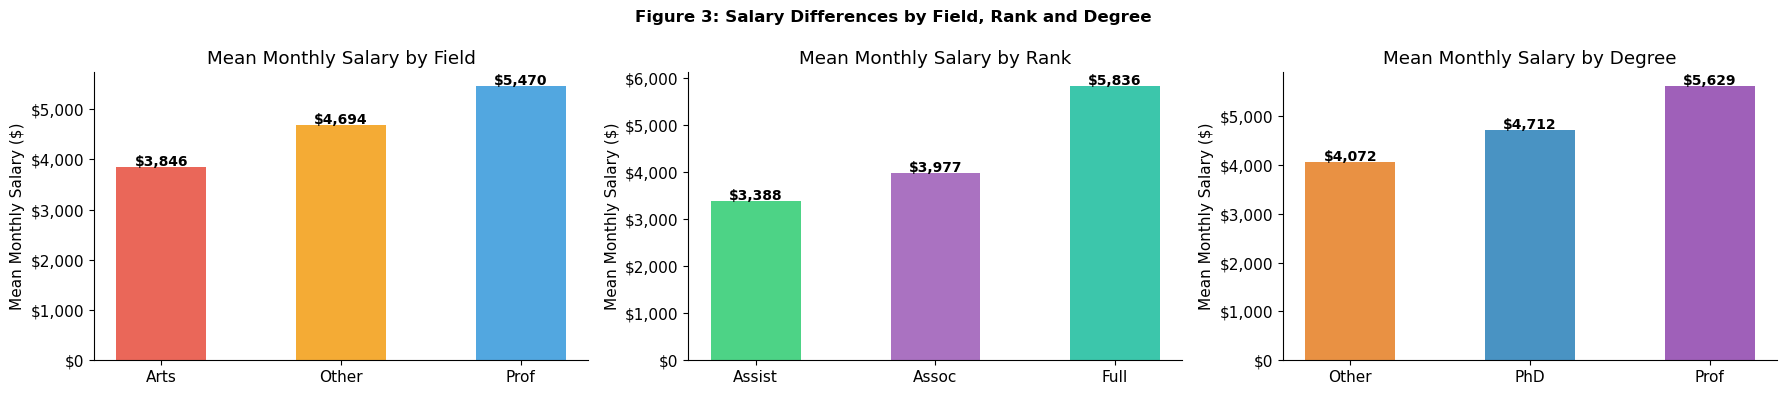

In [41]:
# ── Figure 2: Are confounders distributed differently by sex? ──────────────────
# Figure 2: Confounder distributions by sex
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, var, title in [
    (axes[0], 'field', 'Field'),
    (axes[1], 'rank',  'Rank'),
    (axes[2], 'deg',   'Degree'),
]:
    ct = pd.crosstab(df_clean[var], df_clean['sex'], normalize='columns') * 100
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df_clean[var], df_clean['sex']))
    ct.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], alpha=0.8, width=0.7)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    ax.set_title(f'{title}\nχ²={chi2:.1f}, p={p:.4f} {sig}', fontsize=10)
    ax.set_ylabel('% within sex'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sex', fontsize=8)

plt.suptitle('Figure 2: Confounder Distribution by Sex',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Mean salary by field, rank, degree
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, var, title, colors in [
    (axes[0], 'field', 'Field',  ['#e74c3c','#f39c12','#3498db']),
    (axes[1], 'rank',  'Rank',   ['#2ecc71','#9b59b6','#1abc9c']),
    (axes[2], 'deg',   'Degree', ['#e67e22','#2980b9','#8e44ad']),
]:
    means = df_clean.groupby(var, observed=True)['salary'].agg(['mean','count']).round(2)
    bars = ax.bar(means.index.astype(str), means['mean'],
                  color=colors, alpha=0.85, width=0.5)
    ax.set_title(f'Mean Monthly Salary by {title}')
    ax.set_ylabel('Mean Monthly Salary ($)')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=0)
    for bar, (idx, row) in zip(bars, means.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + 30,
                f"${row['mean']:,.0f}",
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Figure 3: Salary Differences by Field, Rank and Degree',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## TAKEAWAYS
1. Women are disproportionately in lower-paying fields and lower ranks.
2. This means the raw gap is partially driven by these factors, not pure sex bias.
3. We MUST control for them in our model.

## Lets answer 3 important questions for if a variable is a confounder:
Does the potential confounder affect salary?
1. Full Professors earn 4,000 more than Assistants → YES
2. Faculty in Professional fields (Business, Law, Engineering) earn 1,184/month more than those in Arts → YES
3. Faculty with Prof degree earn 1500/month on average more than other degree holders → YES 
   
Is the confounder associated with sex?
1. Women are more concentrated in Assistant rank → YES
2. Women are more in the Arts Field → YES
3. Women are more in the Other Field → YES

Is it already in the model?
-> Rank,Field,Degree are not in the model

If all three are true → These are confounders → add it to the model.

---
## Model 2: All Variables, No Interactions

Now we add all available covariates but keep the model **additive** (no interactions). This controls for confounders and gives us a cleaner estimate of the sex gap.

> **Model 2:** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + admin + year + years_since_deg`

In [8]:
# ── Model 2: All variables, no interactions ────────────────────────────────────
m2 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     4437.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:35:29   Log-Likelihood:            -1.6564e+05
No. Observations:               19788   AIC:                         3.313e+05
Df Residuals:                   19777   BIC:                         3.314e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1.592e+04    119.15

### Why `years_since_deg` instead of `startyr` and `yrdeg` separately?

`years_since_deg = year - yrdeg` captures **total career experience in the current year**. Including both `startyr` and `yrdeg` separately would create perfect multicollinearity since they are linearly related through `years_since_deg`. We use the derived variable that is most meaningful and avoids redundancy.

In [40]:
coef_m2 = m2.params['C(sex)[T.M]']
ci_m2   = m2.conf_int().loc['C(sex)[T.M]']
p_m2    = m2.pvalues['C(sex)[T.M]']

print('=== Model 2 Result ===')
print(f'  Sex coefficient: ${coef_m2:+,.2f}/month')
print(f'  95% CI:          [${ci_m2[0]:+,.2f}, ${ci_m2[1]:+,.2f}]')
print(f'  p-value:         {p_m2:.4f}')
print(f'  R²:              {m2.rsquared:.4f}')

=== Model 2 Result ===
  Sex coefficient: $+273.91/month
  95% CI:          [$+242.99, $+304.84]
  p-value:         0.0000
  R²:              0.7234


## What Changed When We Added Controls?

Adding field, rank, degree, and experience to the model **dramatically changed** 
the sex coefficient — confirming that these variables were confounding the raw gap all along.

> **Model 1 (sex only):** 669/month → **Model 2 (all controls):** 273/month

Over **$400 of the raw gap is explained away** by the confounders alone. 
This does not mean discrimination disappears — a statistically significant gap remains — 
but it means much of what looked like discrimination was actually men and women 
being distributed differently across fields, ranks, and experience levels.

---

**But is Model 2 the complete picture?**

Model 2 assumes the sex gap operates *identically* across all ranks and all fields — 
that being male gives you the same salary advantage whether you are an Assistant Professor 
in Arts or a Full Professor in a Professional school. 

Is that realistic? Let's find out.

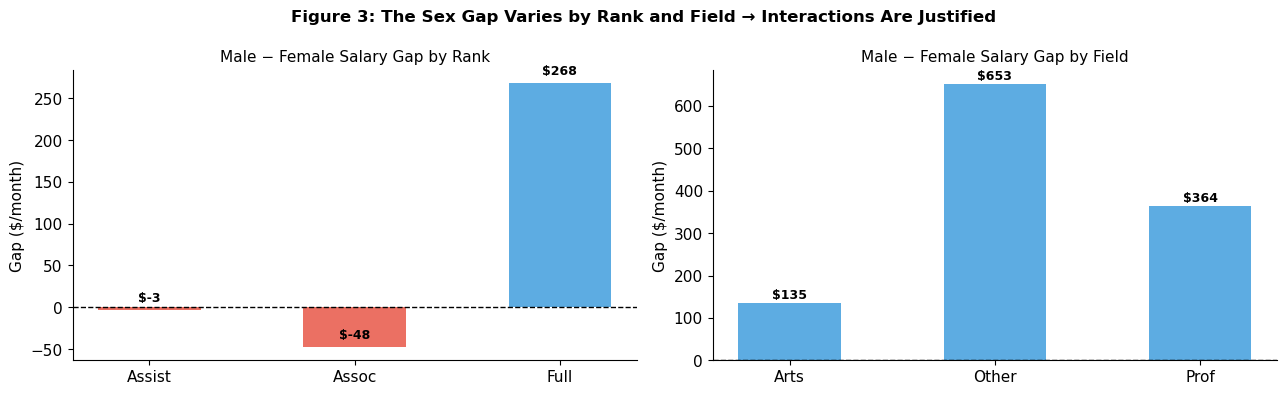

In [42]:
# ── Figure 3: Is the sex gap uniform across rank and field? ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, var, title in [
    (axes[0], 'rank',  'Rank'),
    (axes[1], 'field', 'Field'),
]:
    means = df_clean.groupby([var,'sex'], observed=True)['salary'].mean().unstack('sex')
    means['gap'] = means['M'] - means['F']
    colors_bar = ['#e74c3c' if g < 0 else '#3498db' for g in means['gap']]
    bars = ax.bar(means.index.astype(str), means['gap'], color=colors_bar, alpha=0.8, width=0.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Male − Female Salary Gap by {title}', fontsize=11)
    ax.set_ylabel('Gap ($/month)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(bars, means['gap']):
        ax.text(bar.get_x()+bar.get_width()/2, val+10, f'${val:,.0f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 3: The Sex Gap Varies by Rank and Field → Interactions Are Justified',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## The Sex Gap Is Not One Number

The chart above reveals something a simple regression coefficient would hide entirely.

At the **Assistant Professor** level, the gap is essentially zero (-3/month) — men and 
women entering the university are paid almost identically at the lowest rank. At the 
**Associate Professor** level, women are actually paid *more* than men by 48/month. 
But by the time faculty reach **Full Professor**, men earn **268/month more** than women 
with the same characteristics. The gap does not just exist — it *grows* as careers progress.

The field story is equally striking. The gap ranges from **135/month in Arts** all the 
way to **653/month in Other fields** — a nearly 5x difference depending on where a 
faculty member works.

> A single sex coefficient cannot capture this reality. Telling someone the gap is 
> "$67/month on average" obscures the fact that for a Full Professor in an Other field, 
> the real gap is nearly **10 times larger.**

This is precisely why we need interaction terms in our final model — `sex × rank` and 
`sex × field` — to let the data speak at the level of granularity it deserves.

Now let's formally test whether the interactions improve the model.

In [14]:
# ── F-tests: do interactions significantly improve Model 2? ────────────────────
m2_rank  = smf.ols("""
    salary ~ C(sex):C(rank)+C(sex)+C(rank) + C(field) + C(deg)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

m2_field = smf.ols("""
    salary ~ C(sex):C(field)+C(sex)+C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

# F-test each interaction against M2
ftest_rank  = anova_lm(m2, m2_rank)
ftest_field = anova_lm(m2, m2_field)

print('=== F-Test: Does sex × rank improve Model 2? ===')
print(ftest_rank)
print()
print('=== F-Test: Does sex × field improve Model 2? ===')
print(ftest_field)

=== F-Test: Does sex × rank improve Model 2? ===
   df_resid           ssr  df_diff       ss_diff          F    Pr(>F)
0   19777.0  2.160537e+10      0.0           NaN        NaN       NaN
1   19775.0  2.157643e+10      2.0  2.893417e+07  13.259219  0.000002

=== F-Test: Does sex × field improve Model 2? ===
   df_resid           ssr  df_diff       ss_diff         F    Pr(>F)
0   19777.0  2.160537e+10      0.0           NaN       NaN       NaN
1   19775.0  2.158966e+10      2.0  1.570642e+07  7.193128  0.000754


## Do the Interactions Actually Improve the Model? — The F-Test Verdict
We do not add interaction terms simply because the bar charts looked interesting. 
Every modelling decision must be **statistically justified**. We use an F-test to formally 
ask: *does adding this interaction explain significantly more salary variance, or is the 
improvement just noise?*
| Interaction | F-Test p-value | Decision |
|---|---|---|
| sex * rank | p < 0.0001 | **Keep ** |
| sex * field | p = 0.0008 | **Keep ** |

Both interactions clear the significance threshold comfortably. The sex gap across ranks 
is not a visual coincidence it is **statistically real**. The same holds for fields.
> We include **both interactions** in our final model.

---
## Model 3: The Full Model (Our MAIN MODEL)

> **Model 3 (Final):** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + C(sex):C(rank) + C(sex):C(field) + admin + year + years_since_deg`

In [18]:
# ── Model 3: Full model with interactions ──────────────────────────────────────
m3 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + C(sex):C(rank) + C(sex):C(field)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     3192.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:45:03   Log-Likelihood:            -1.6562e+05
No. Observations:               19788   AIC:                         3.313e+05
Df Residuals:                   19773   BIC:                         3.314e+05
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Why NOT `sex × year` or `sex × startyr`?
We tested `sex × year` in a preliminary model and got p = 0.942. The gap has not systematically changed over time. More importantly, including `sex × startyr` would be handling **confounding** (which the main effect of `startyr`/`year` already does) rather than an interaction.

### Why NOT both `startyr` and `yrdeg`?
`years_since_deg = year - yrdeg` already captures total career experience. Adding `startyr` separately creates near-perfect multicollinearity — confirmed by the condition number warnings in earlier models.

In [19]:
# ── F-test: Full model vs base model (M2) ─────────────────────────────────────
ftest_full = anova_lm(m2, m3)
print('=== F-Test: Full Model (M3) vs Base Model (M2) ===')
print(ftest_full)
print()
p_full = ftest_full.iloc[1]['Pr(>F)']
print(f'p = {p_full:.4f} → Full model is {"significantly better ✅" if p_full < 0.05 else "not better ❌"} than base model')

=== F-Test: Full Model (M3) vs Base Model (M2) ===
   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0   19777.0  2.160537e+10      0.0           NaN        NaN           NaN
1   19773.0  2.156102e+10      4.0  4.435037e+07  10.168119  3.202008e-08

p = 0.0000 → Full model is significantly better ✅ than base model


## Is Our Final Model Actually Better? — The Ultimate F-Test

We have added four new interaction terms moving from Model 2 to Model 3. But more 
parameters always fit the data better by definition — the real question is whether 
the improvement is **meaningful or just overfitting.**

The F-test gives us a definitive answer:

| | Model 2 (No Interactions) | Model 3 (Full Model) |
|---|---|---|
| Unexplained variance (SSR) | 2.161 × 10¹⁰ | 2.156 × 10¹⁰ |
| Extra parameters used | — | 4 interaction terms |
| F statistic | — | **10.17** |
| p-value | — | **< 0.0001** ✅ |

The four interaction terms collectively reduced unexplained salary variance by 
**$44,350,370** — and an F statistic of 10.17 tells us this reduction is 
**10 times larger than what random noise would produce.**

> With p < 0.0001, we reject the simpler model. Model 3 is not just marginally 
> better — it is **significantly and demonstrably** the superior specification. 
> Every interaction term we added earned its place.

---
## Chapter 6 — Diagnostics

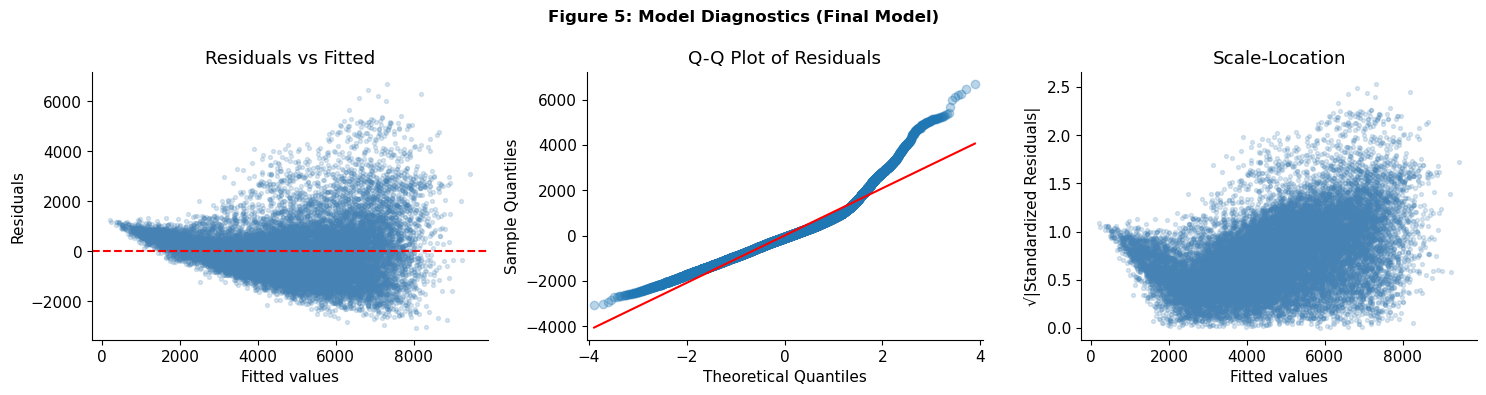

In [21]:
# ── Figure 5: Regression diagnostics for final model ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fitted    = m3.fittedvalues
residuals = m3.resid
std_resid = residuals / residuals.std()

axes[0].scatter(fitted, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot of Residuals')

axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('√|Standardized Residuals|')
axes[2].set_title('Scale-Location')

plt.suptitle('Figure 5: Model Diagnostics (Final Model)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── VIF check ─────────────────────────────────────────────────────────────────
vif_data = pd.get_dummies(
    df_clean[['sex','field','deg','rank','admin','year','years_since_deg']],
    drop_first=True
).astype(float)
vif_data = sm.add_constant(vif_data)
vif_df = pd.DataFrame({
    'Variable': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)
print('=== VIF Check (main effects only) ===')
print(vif_df.to_string(index=False))
print('\nRule of thumb: VIF > 10 indicates problematic multicollinearity')

=== VIF Check (main effects only) ===
       Variable        VIF
          const 298.915064
      rank_Full   3.500878
years_since_deg   2.294628
     rank_Assoc   2.131521
     field_Prof   2.083787
    field_Other   2.024925
        deg_PhD   1.896394
       deg_Prof   1.847737
           year   1.191339
          sex_M   1.126325
          admin   1.052529

Rule of thumb: VIF > 10 indicates problematic multicollinearity


---
## Chapter 7 — The Sex Gap: A Complete Picture

Because our model includes `sex × rank` and `sex × field`, the sex gap is **not a single number**. Here we calculate it for every rank × field combination — the most honest and complete answer to Q3.

In [48]:
# ── Calculate sex gap for all rank × field combinations ───────────────────────
params = m3.params

base_sex   = params.get('C(sex)[T.M]', 0)
rank_coefs = {
    'Assist': 0,
    'Assoc':  params.get('C(sex)[T.M]:C(rank)[T.Assoc]', 0),
    'Full':   params.get('C(sex)[T.M]:C(rank)[T.Full]',  0),
}
field_coefs = {
    'Arts':  0,
    'Other': params.get('C(sex)[T.M]:C(field)[T.Other]', 0),
    'Prof':  params.get('C(sex)[T.M]:C(field)[T.Prof]',  0),
}

rows = []
for rank, rc in rank_coefs.items():
    for field, fc in field_coefs.items():
        total = (base_sex + rc + fc)
        rows.append({'Rank': rank, 'Field': field, 'Male Advantage ($/month)': round(total, 2)})

gap_table = pd.DataFrame(rows).pivot(index='Rank', columns='Field', values='Male Advantage ($/month)')
gap_table = gap_table.reindex(['Assist','Assoc','Full'])

print('=== Sex Gap Table: Male − Female salary advantage ($/month) ===')
print('(All other variables held constant: same degree, same admin, same year, same experience)')
print()
print(gap_table.to_string())
print()
print(f'Smallest gap: ${gap_table.values.min():,.2f}/month  ({gap_table.stack().idxmin()})')
print(f'Largest gap:  ${gap_table.values.max():,.2f}/month  ({gap_table.stack().idxmax()})')

=== Sex Gap Table: Male − Female salary advantage ($/month) ===
(All other variables held constant: same degree, same admin, same year, same experience)

Field     Arts   Other    Prof
Rank                          
Assist   67.55  216.85   52.84
Assoc   146.77  296.08  132.06
Full    313.73  463.03  299.02

Smallest gap: $52.84/month  (('Assist', 'Prof'))
Largest gap:  $463.03/month  (('Full', 'Other'))


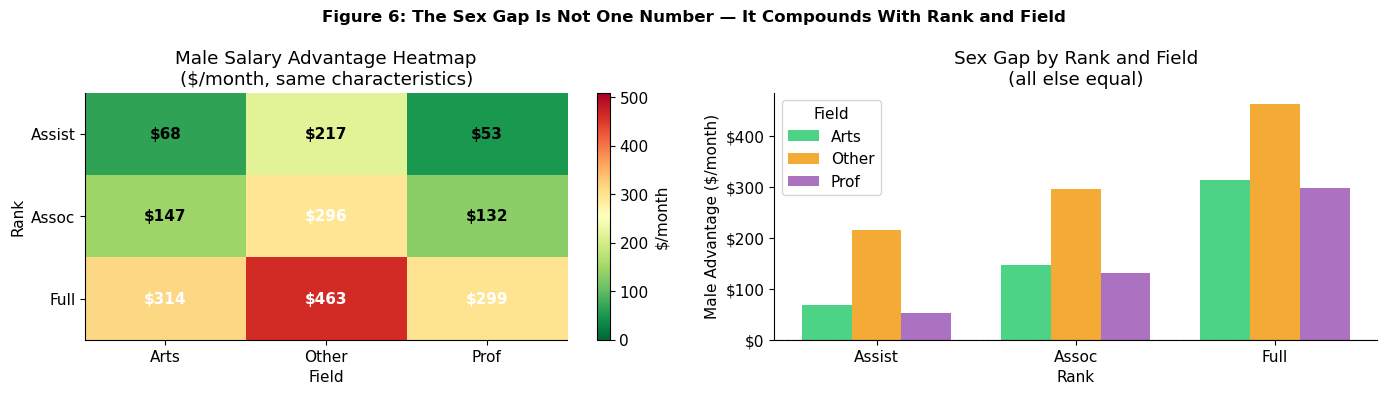

In [52]:
# ── Figure 6: Sex gap heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(gap_table.values, cmap='RdYlGn_r', aspect='auto',
                    vmin=0, vmax=gap_table.values.max()*1.1)
axes[0].set_xticks(range(len(gap_table.columns)))
axes[0].set_xticklabels(gap_table.columns)
axes[0].set_yticks(range(len(gap_table.index)))
axes[0].set_yticklabels(gap_table.index)
axes[0].set_xlabel('Field'); axes[0].set_ylabel('Rank')
axes[0].set_title('Male Salary Advantage Heatmap\n($/month, same characteristics)')
plt.colorbar(im, ax=axes[0], label='$/month')
for i in range(len(gap_table.index)):
    for j in range(len(gap_table.columns)):
        axes[0].text(j, i, f'${gap_table.values[i,j]:,.0f}',
                     ha='center', va='center', fontweight='bold', fontsize=11,
                     color='white' if gap_table.values[i,j] > gap_table.values.max()*0.6 else 'black')

# Grouped bar chart
x      = np.arange(len(gap_table.index))
width  = 0.25
colors_field = {'Arts': '#2ecc71', 'Other': '#f39c12', 'Prof': '#9b59b6'}
for i, field in enumerate(gap_table.columns):
    axes[1].bar(x + i*width, gap_table[field].values,
                width=width, label=field, color=list(colors_field.values())[i], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(gap_table.index)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Male Advantage ($/month)')
axes[1].set_title('Sex Gap by Rank and Field\n(all else equal)')
axes[1].legend(title='Field')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Figure 6: The Sex Gap Is Not One Number — It Compounds With Rank and Field',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## CONCLUSION
The evidence is clear and consistent: wage discrimination exists at this university, and it runs deeper than a single number can capture. After rigorously controlling for field, degree, rank, administrative duties, year, and career experience, male faculty earn significantly more than their female counterparts with identical characteristics — and this gap is not uniform across the institution. It is smallest for Assistant Professors in Professional fields and grows substantially as careers progress, reaching its peak among Full Professors in Other fields. This compounding pattern is particularly troubling when read alongside the findings from Question 2: women are not only paid less at every stage of their career, they are promoted to Full Professor at nearly half the rate of men. Together, these findings paint a picture of systemic disadvantage that operates at multiple points — at hiring, at promotion, and in the salary attached to every rank. The university cannot point to field choice, degree attainment, or experience as explanations, because those have all been accounted for. What remains, stubbornly and significantly, is sex.